In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib.testing import parametrize

In [5]:
from sklearn.datasets import fetch_california_housing

In [6]:
df = fetch_california_housing()

In [7]:
dataset = pd.DataFrame(df.data)

In [8]:
dataset.columns = df.feature_names

In [9]:
dataset.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
## independent and dependent features
x = dataset
y = df.target

In [11]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

In [12]:
## train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 0)

In [13]:
## standardizing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression, ridge_regression

In [15]:
from sklearn.model_selection import cross_val_score

In [16]:
regression = LinearRegression()
regression.fit(X_train, y_train)
mse = cross_val_score(regression, X_train, y_train, cv=10)

In [17]:
np.mean(mse)

0.6062789167942275

In [18]:
reg_pred = regression.predict(X_test)

In [19]:
import seaborn as sns

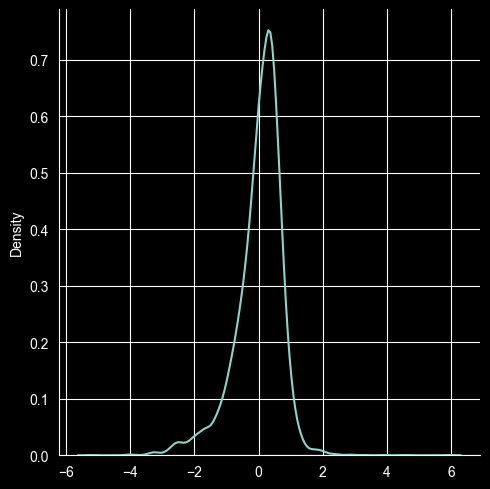

In [20]:
sns.displot(reg_pred - y_test,kind="kde")

In [21]:
from sklearn.metrics import r2_score

In [22]:
score = r2_score(reg_pred, y_test)

In [23]:
score

0.34377807614318223

In [24]:
from sklearn.linear_model import Ridge

In [25]:
from sklearn.model_selection import GridSearchCV

In [26]:
ridge_regressor = Ridge()

In [27]:
ridge_regressor

Ridge()

In [28]:
parameters= {'alpha' : [1,5,10,20,30,40,50,60,70,80,90]}
ridgecv=GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)

In [29]:
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90]},
             scoring='neg_mean_squared_error')

In [30]:
print(ridgecv.best_params_)

{'alpha': 30}


In [31]:
print(ridgecv.best_score_)

-0.5221707844559109


In [32]:
ridge_pred= ridgecv.predict(X_test)

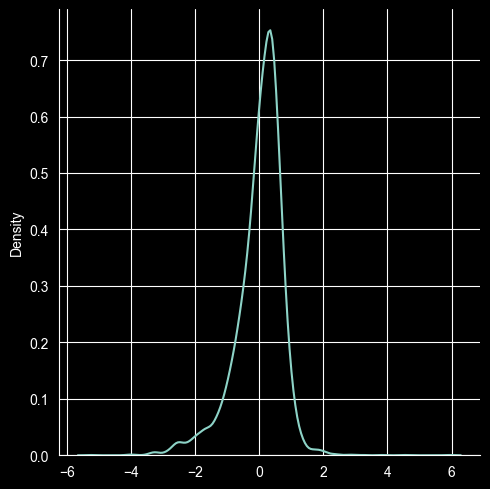

In [33]:
sns.displot(ridge_pred-y_test,kind="kde")

In [34]:
score2= r2_score(ridge_pred, y_test)

In [35]:
print(score2)

0.3358949075710844


In [36]:
from sklearn.linear_model import Lasso

In [37]:
lasso= Lasso()

In [38]:
parameters= {'alpha' : [1,5,10,20,30,40,50,60,70,80,90]}
lassocv=GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90]},
             scoring='neg_mean_squared_error')

In [39]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 1}
-1.330905203097798


In [40]:
lasso_pred=lassocv.predict(X_test)

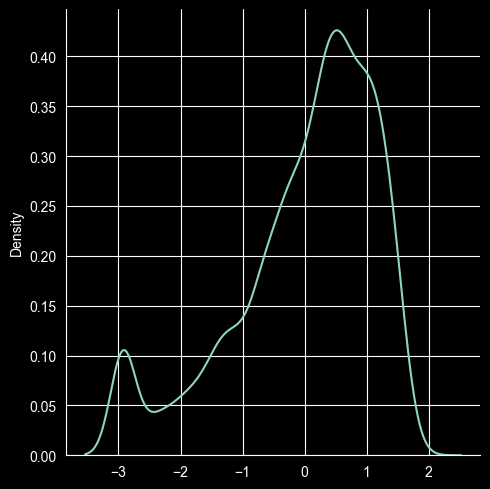

In [41]:
sns.displot(lasso_pred-y_test,kind="kde")

In [42]:
score3=r2_score(lasso_pred, y_test)

In [43]:
score3

-6.76031918298324e+30